# **NLP Practical 6**
---
**Name: Shubham Sarwar**<br>
**PRN: 202301040127**



In [ ]:
!pip install nltk wordcloud seaborn

import nltk
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import heapq

from nltk.corpus import stopwords
from wordcloud import WordCloud


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**Text Corpus**

In [ ]:
text = """A week ago a friend invited a couple of other couples over for dinner. Eventually, the food (but not the wine) was cleared off the table for what turned out to be some fierce Scrabbling. Heeding the strategy of going for the shorter, more valuable word over the longer cheaper word, our final play was “Bon,” which–as luck would have it!–happens to be a Japanese Buddhist festival, and not, as I had originally asserted while laying the tiles on the board, one half of a chocolate-covered cherry treat. Anyway, the strategy worked. My team only lost by 53 points instead of 58.

Just the day before, our host had written of the challenges of writing short. In journalism–my friend’s chosen trade, and mostly my own, too–Mark Twain’s observation undoubtedly applies: “I didn’t have time to write a short letter, so I wrote a long one instead.” The principle holds across genres, in letters, reporting, and other writing. It’s harder to be concise than to blather. (Full disclosure, this blog post will clock in at a blather-esque 803 words.) Good writing is boiled down, not baked full of air like a souffl??. No matter how yummy souffl??s may be. Which they are. Yummy like a Grisham novel.

Lately, I’ve been noticing how my sentences have a tendency to keep going when I write them onscreen. This goes for concentrated writing as well as correspondence. (Twain probably believed that correspondence, in an ideal world, also demands concentration. But he never used email.) Last week I caught myself packing four conjunctions into a three-line sentence in an email. That’s inexcusable. Since then, I have tried to eschew conjunctions whenever possible. Gone are the commas, the and’s, but’s, and so’s; in are staccato declaratives. Better to read like bad Hemingway than bad Faulkner.

Length–as we all know, and for lack of a more original or effective way of saying it–matters. But (ahem), it’s also a matter of how you use it. Style and length are technically two different things."""

**Preprocessing and Tokenization**

In [ ]:
dataset = nltk.sent_tokenize(text)

# Cleaning
for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

# Print cleaned sentences
for i, sentence in enumerate(dataset):
    print(f"Sentence {i+1}: {sentence}")


Sentence 1: a week ago a friend invited a couple of other couples over for dinner 
Sentence 2: eventually the food but not the wine was cleared off the table for what turned out to be some fierce scrabbling 
Sentence 3: heeding the strategy of going for the shorter more valuable word over the longer cheaper word our final play was bon which as luck would have it happens to be a japanese buddhist festival and not as i had originally asserted while laying the tiles on the board one half of a chocolate covered cherry treat 
Sentence 4: anyway the strategy worked 
Sentence 5: my team only lost by 53 points instead of 58 
Sentence 6: just the day before our host had written of the challenges of writing short 
Sentence 7: in journalism my friend s chosen trade and mostly my own too mark twain s observation undoubtedly applies i didn t have time to write a short letter so i wrote a long one instead the principle holds across genres in letters reporting and other writing 
Sentence 8: it s hard

**Word Count**

In [ ]:
word2count = {}

for data in dataset:
    words = nltk.word_tokenize(data)
    for word in words:
        if word not in word2count:
            word2count[word] = 1
        else:
            word2count[word] += 1


**Selecting Top N Frequent Words**

In [ ]:
stop_words = set(stopwords.words('english'))
filtered_word2count = {
    word: count for word, count in word2count.items()
    if word not in stop_words
}

# Convert to DataFrame
word_freq_df = pd.DataFrame(
    list(filtered_word2count.items()),
    columns=['Word', 'Frequency']
)

word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

print("\nWord Frequency Table:\n")
print(word_freq_df.head(20))



Word Frequency Table:

               Word  Frequency
55          writing          4
92             like          3
20             word          2
2            friend          2
0              week          2
56            short          2
62            twain          2
80             full          2
67            write          2
37              one          2
49          instead          2
17            going          2
16         strategy          2
93           souffl          2
94           matter          2
95            yummy          2
108  correspondence          2
118           email          2
123    conjunctions          2
113            also          2


**Visualization: Bar Chart**


Top 10 frequent words: ['writing', 'like', 'week', 'friend', 'strategy', 'going', 'word', 'one', 'instead', 'short']


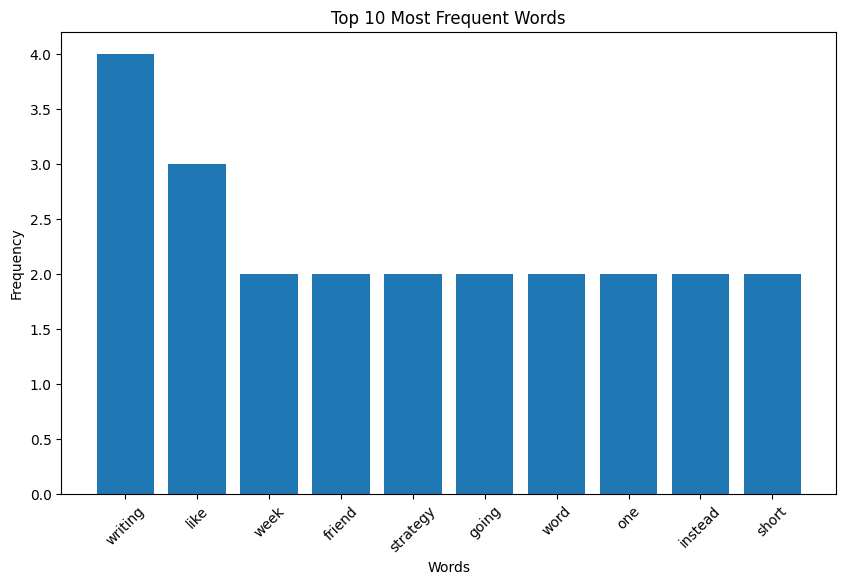

In [ ]:
freq_words = heapq.nlargest(10, filtered_word2count, key=filtered_word2count.get)
print("\nTop 10 frequent words:", freq_words)

# Bar chart
top_words = sorted(filtered_word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

**Creating Bag of Word Model & Visualization: Heat Map**

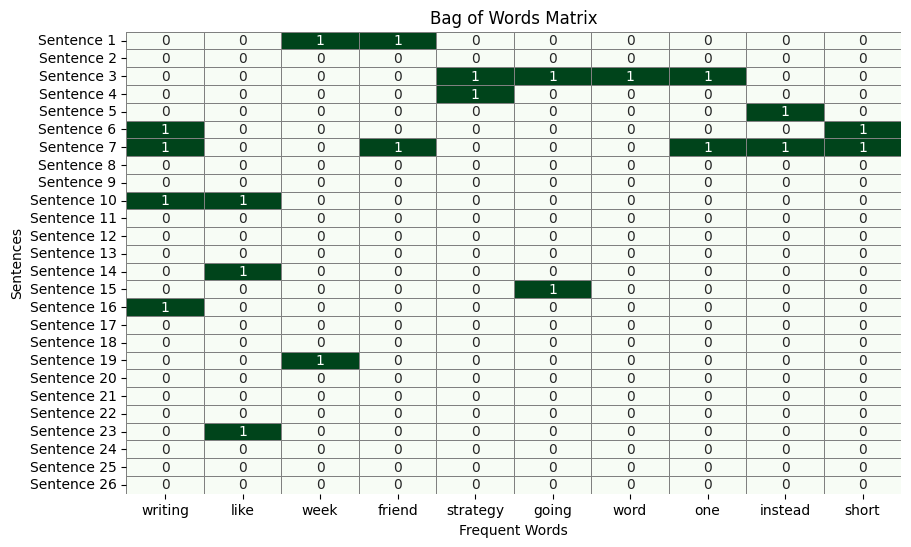

In [ ]:
X = []

for data in dataset:
    vector = []
    words = nltk.word_tokenize(data)
    for word in freq_words:
        if word in words:
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    X,
    cmap='Greens',
    cbar=False,
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor='grey',
    xticklabels=freq_words,
    yticklabels=[f"Sentence {i+1}" for i in range(len(dataset))]
)

plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

**Visulization: Word Cloud**

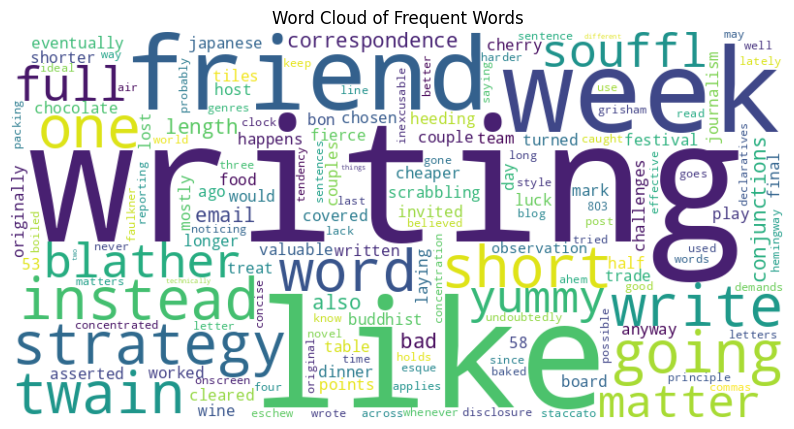

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(filtered_word2count)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequent Words")
plt.show()